Leaf Classification

The purpose of this task is to classify leaf images using supervised machine learning. In the end the models are going to predict in which category does an unseen leaf belong to. In the beginning relevant features are extracted from the data like the glcm scores and different color channel value means and variances. These features form a feature vector that corresponds to each row of the original leaf data. This feature vector is used in training the different models to find similarities which indicate that a certain leaf belongs to a certain class.

The dataset consists of three leaf classes Basil, Lemon and Chinar. The original images contain RGB values which need to be converted to grayscale for the purpose of the analysis. The images are sourced from Kaggle.

To train the classifiers the following methods are used Ridge Classifier, Random Forest and Multi-Layer Perceptron.

# Leaf Classification

In [19]:
#All imports are done here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski

#Scikit-learn methods
import sklearn as sk
import sklearn.preprocessing as skp
import sklearn.linear_model as sklm
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


#For future proof image handling instead of skimage.io
import imageio.v3 as iio

#For reading files from folders
from pathlib import Path

#Computer vision
import cv2 as cv

#For data visualization
import seaborn as sns

## Data Preparation

In [20]:
#Import all images to their own list
basil = []
for file in Path('Basil').iterdir():
  if not file.is_file():
    continue

  basil.append(iio.imread(file))

chinar = []
for file in Path('Chinar').iterdir():
  if not file.is_file():
    continue

  chinar.append(iio.imread(file))

lemon = []
for file in Path('Lemon').iterdir():
  if not file.is_file():
    continue

  lemon.append(iio.imread(file))

In [21]:
#Converting all images to 3-bit grayscale
#and saving them and each color channel to their own list
categories = [basil, chinar, lemon]
all_gray = []
all_red = []
all_green = []
all_blue = []

for leaves in categories:
  for leaf in leaves:
    grayLeaf = ski.color.rgb2gray(leaf)
    grayLeaf = np.uint8(np.clip(grayLeaf * 8, 0, 7))
    all_gray.append(grayLeaf)
    all_blue.append(leaf[:,:,0])
    all_green.append(leaf[:,:,1])
    all_red.append(leaf[:,:,2])

In [22]:
#Combining all images into one list and listing all the labels

#Images: 184, 120, 180
X = np.stack(all_gray)
X_width = X[:, ]

#Labels 0: basil, 1: chinar, 2: lemon
Y = np.concatenate([
    np.zeros(len(basil), dtype=int),
    np.ones(len(chinar), dtype=int),
    np.full(len(lemon), 2, dtype=int)
])

## Feature Extraction

### First order texture measures

In [23]:
#Mean values for each image and each RGB channel
#Result is the average value for a single image and a single color

all_red = np.array(all_red)
red_mean = np.mean(all_red, axis=(1,2))

all_green = np.array(all_green)
green_mean = np.mean(all_green, axis=(1,2))


all_blue = np.array(all_blue)
blue_mean = np.mean(all_blue, axis=(1,2))


In [24]:
#Variance values for each image and each RGB channel
#Result is the average value for a single image and a single color

red_var = np.var(all_red, axis=(1,2))
green_var = np.var(all_green, axis=(1,2))
blue_var = np.var(all_blue, axis=(1,2))

### Second order texture measures

In [25]:
#Gray-Level Co-Occurrence Matrix (GLCM)
#Correlation for GLCM means how similar each pixel is to it's neighbours.
#High correlation means there is less "texture" in the image so the whole image is more homogenous.

glcm_vertical_1 = []
glcm_vertical_2 = []
glcm_horizontal_1 = []
glcm_horizontal_2 = []

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[1], angles=[0], levels=8, symmetric=False, normed=True 
  )
  glcm_horizontal_1.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_horizontal_1 = np.array(glcm_horizontal_1)

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[2], angles=[0], levels=8, symmetric=False, normed=True 
  )
  glcm_horizontal_2.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_horizontal_2 = np.array(glcm_horizontal_2)

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[1], angles=[np.pi/2], levels=8, symmetric=False, normed=True 
  )
  glcm_vertical_1.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_vertical_1 = np.array(glcm_vertical_1)

for leaf in X:
  glcm = ski.feature.graycomatrix(
    leaf, distances=[2], angles=[np.pi/2], levels=8, symmetric=False, normed=True 
  )
  glcm_vertical_2.append(ski.feature.graycoprops(glcm, 'correlation')[0, 0])

glcm_vertical_2 = np.array(glcm_vertical_2)

In [26]:
#Creation of the feature vector that combines all of the extracted features

feature_vector = pd.concat([
  pd.DataFrame(Y),
  pd.DataFrame(red_mean),
  pd.DataFrame(red_var),
  pd.DataFrame(green_mean),
  pd.DataFrame(green_var),
  pd.DataFrame(blue_mean),
  pd.DataFrame(blue_var),
  pd.DataFrame(glcm_vertical_1),
  pd.DataFrame(glcm_vertical_2),
  pd.DataFrame(glcm_horizontal_1),
  pd.DataFrame(glcm_horizontal_2),
], axis=1)

feature_vector = feature_vector.set_axis([
  'leaf',
  'red_mean',
  'red_var',
  'green_mean', 
  'green_var', 
  'blue_mean', 
  'blue_var', 
  'glcm_vertical_1', 
  'glcm_vertical_2', 
  'glcm_horizontal_1', 
  'glcm_horizontal_2'
  ], axis=1)

## Additional image-based features

In [27]:
#For each type of leaf finding the template leaf by the highest glcm_mean value

feature_vector['glcm_mean'] = feature_vector[[
  'glcm_vertical_1', 
  'glcm_vertical_2', 
  'glcm_horizontal_1', 
  'glcm_horizontal_2'
  ]].mean(axis=1)

idx = (feature_vector.groupby('leaf')['glcm_mean'].transform(max) == feature_vector['glcm_mean'])
template_leaves = feature_vector[idx]

In [28]:
#Comparing each leaf to each template leaf and adding the result to the feature vector

basil_scores = []
chinar_scores = []
lemon_scores = []

basil_template = all_gray[template_leaves['leaf'].index[0]]
chinar_template = all_gray[template_leaves['leaf'].index[1]]
lemon_template = all_gray[template_leaves['leaf'].index[2]]

for leaf in all_gray:
  res = cv.matchTemplate(leaf, basil_template, cv.TM_CCOEFF_NORMED)
  basil_scores.append(res.max())

for leaf in all_gray:
  res = cv.matchTemplate(leaf, chinar_template, cv.TM_CCOEFF_NORMED)
  chinar_scores.append(res.max())

for leaf in all_gray:
  res = cv.matchTemplate(leaf, lemon_template, cv.TM_CCOEFF_NORMED)
  lemon_scores.append(res.max())

template_matching_scores = pd.DataFrame([basil_scores, chinar_scores, lemon_scores])

template_matching_scores = template_matching_scores.T
template_matching_scores.columns = ['basil_match', 'chinar_match', 'lemon_match']

feature_vector = pd.concat([feature_vector, template_matching_scores], axis=1)

In [29]:
#Preparing labels and scaling features

y = feature_vector['leaf']
y.columns = ['leaf']
feature_vector_complete = feature_vector.drop(['leaf','glcm_mean'], axis=1)

scaler = skp.StandardScaler()
X = pd.DataFrame(scaler.fit_transform(feature_vector_complete))
X.columns = feature_vector_complete.columns

feature_vector_scaled = pd.concat([y,X], axis=1)

# Feature Relationships

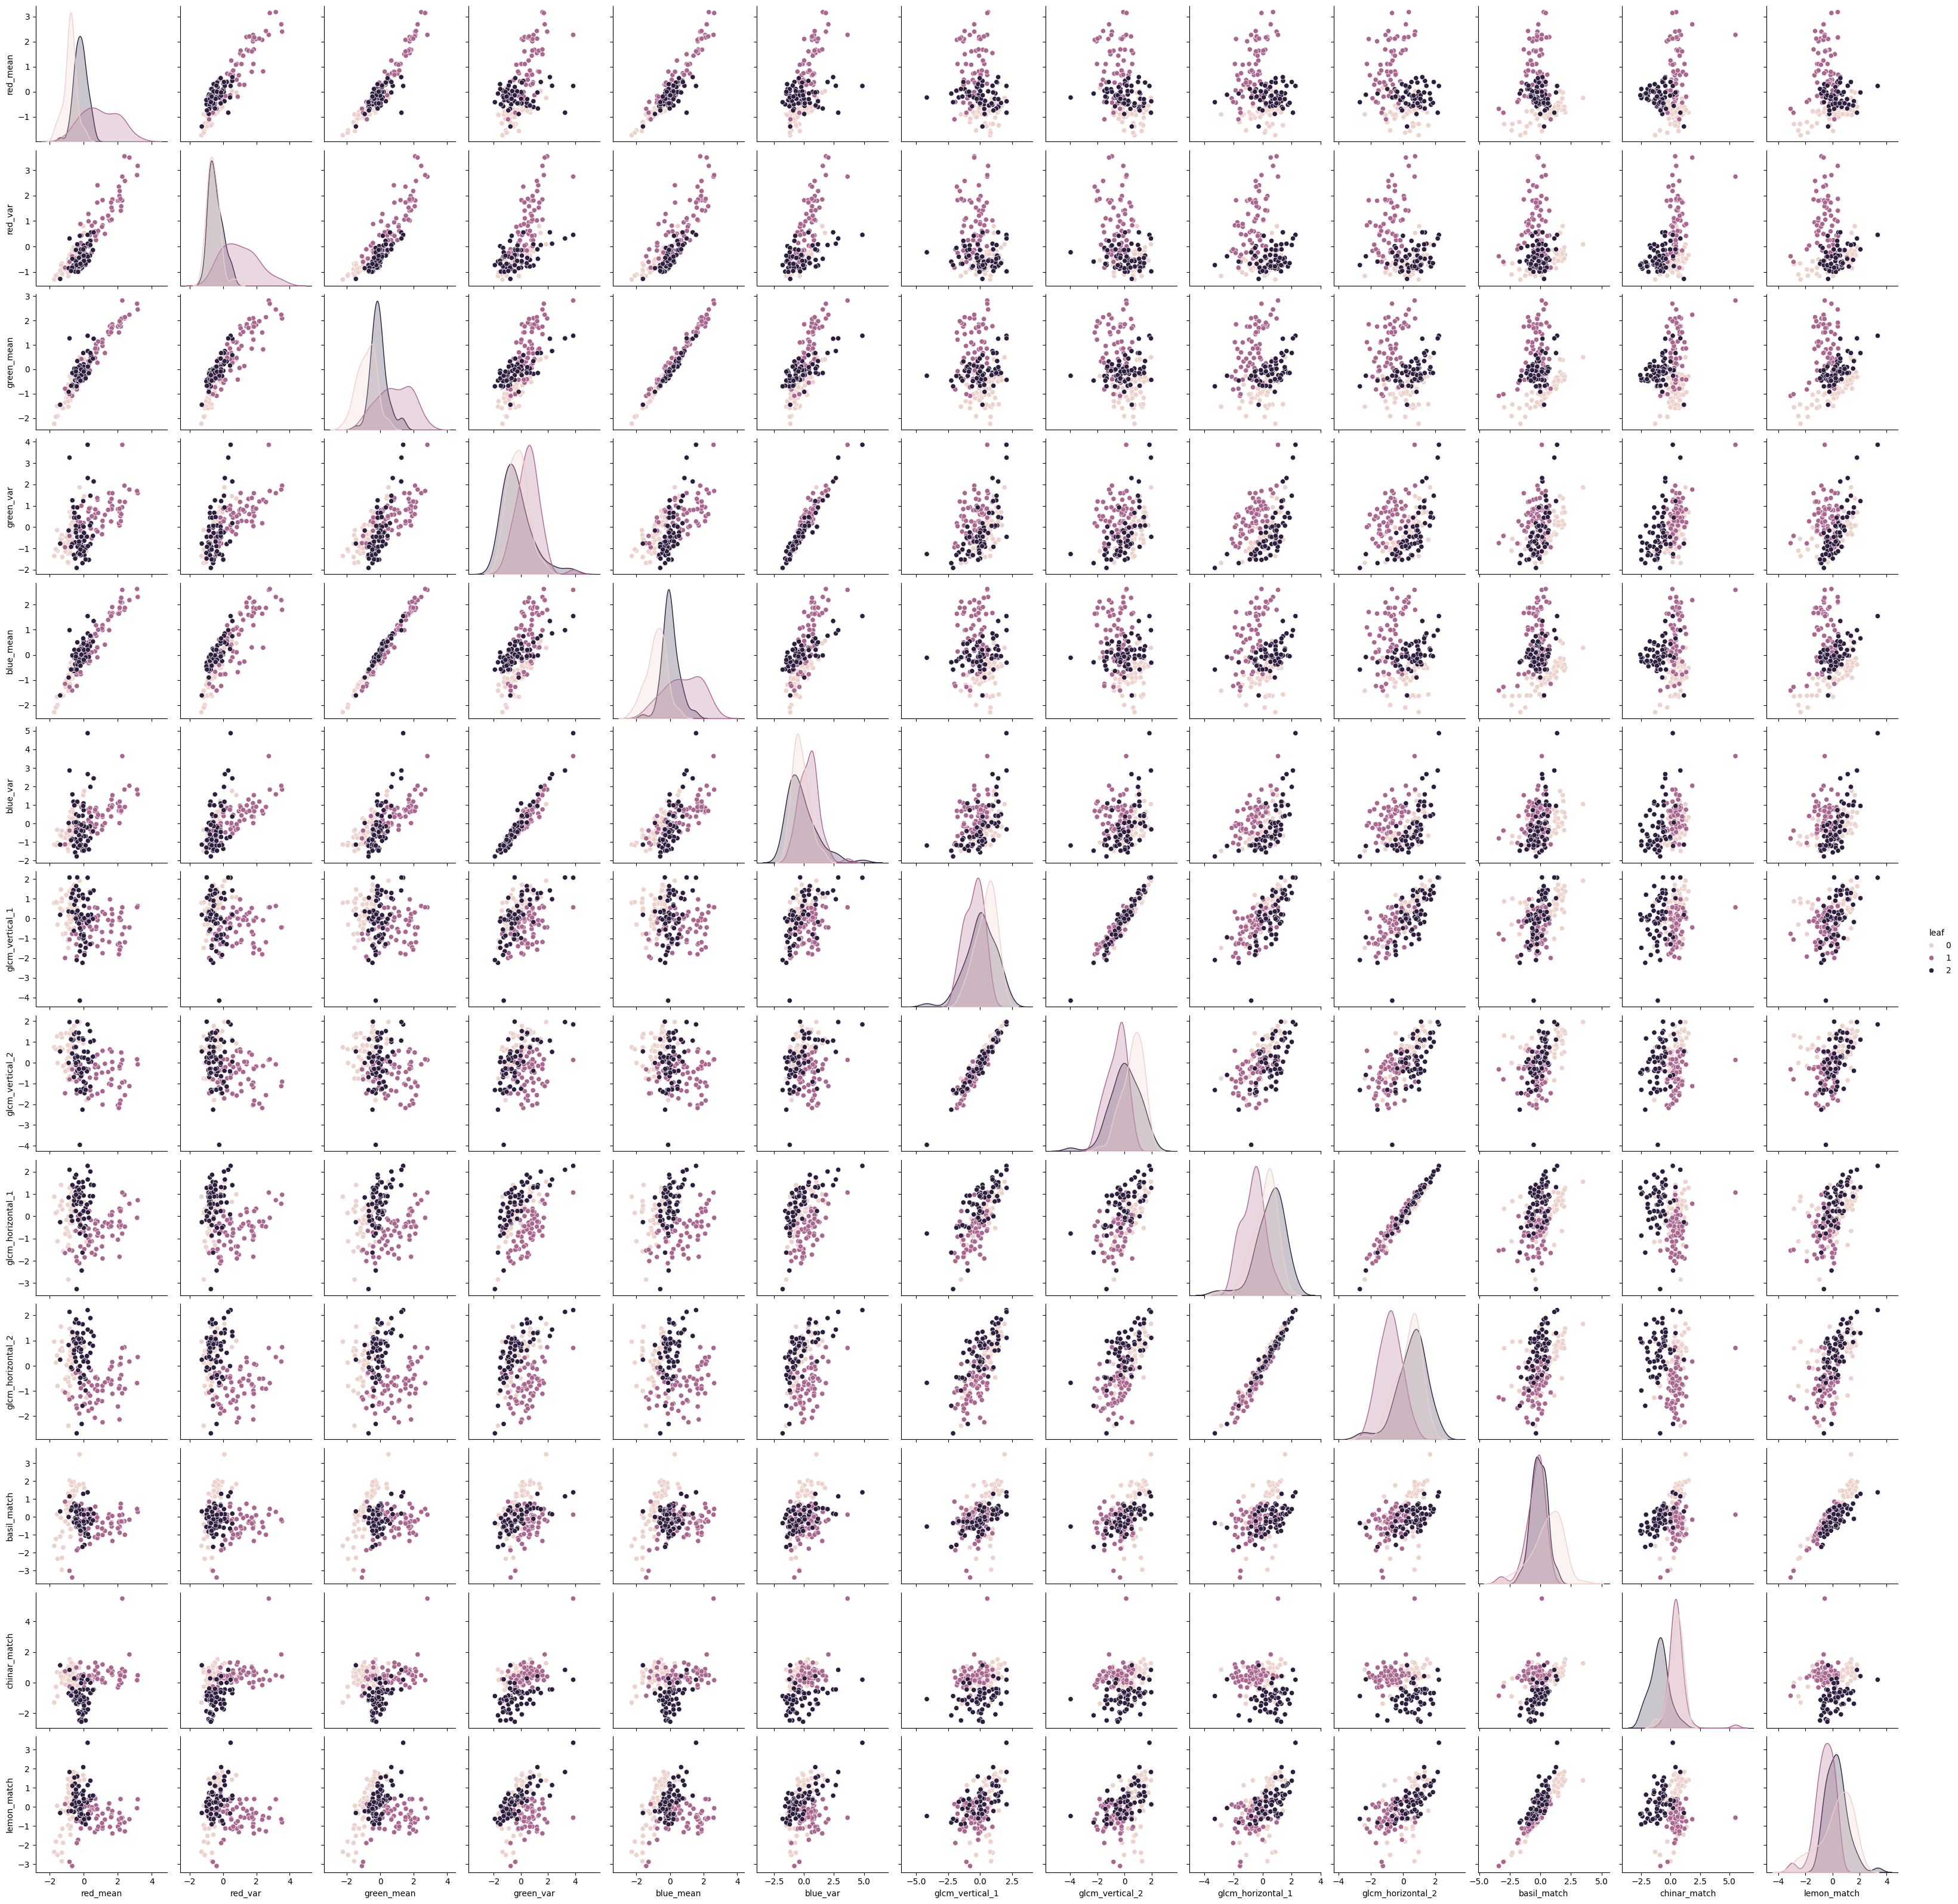

In [30]:
#Pairplot for each feature
sns.pairplot(feature_vector_scaled, hue='leaf')

The following features show approximately linear dependence:
- 2,1 = red_var, red_mean
- 3,1 = green_mean, red_mean
- 3,2 = green_mean red_var
- 5,1 = blue_mean, red_mean
- 5,2 = blue_mean, red_var
- 5,3 = blue_mean, green_mean
- 6,4 = blue_var, green_var
- 8,7 = glcm_vertiacl_2, glcm_vertiacl_1
- 10,9 = glcm_horizontal_2, glcm_horizontal_1
- 13,11 = lemon_match, basil_match

Many of the color features seem to be dependent as are the vertical and horizontal glcm values with each other. The templates of lemons and basil seem to be dependent, which seems to be true based on visual analysis of the leaves.

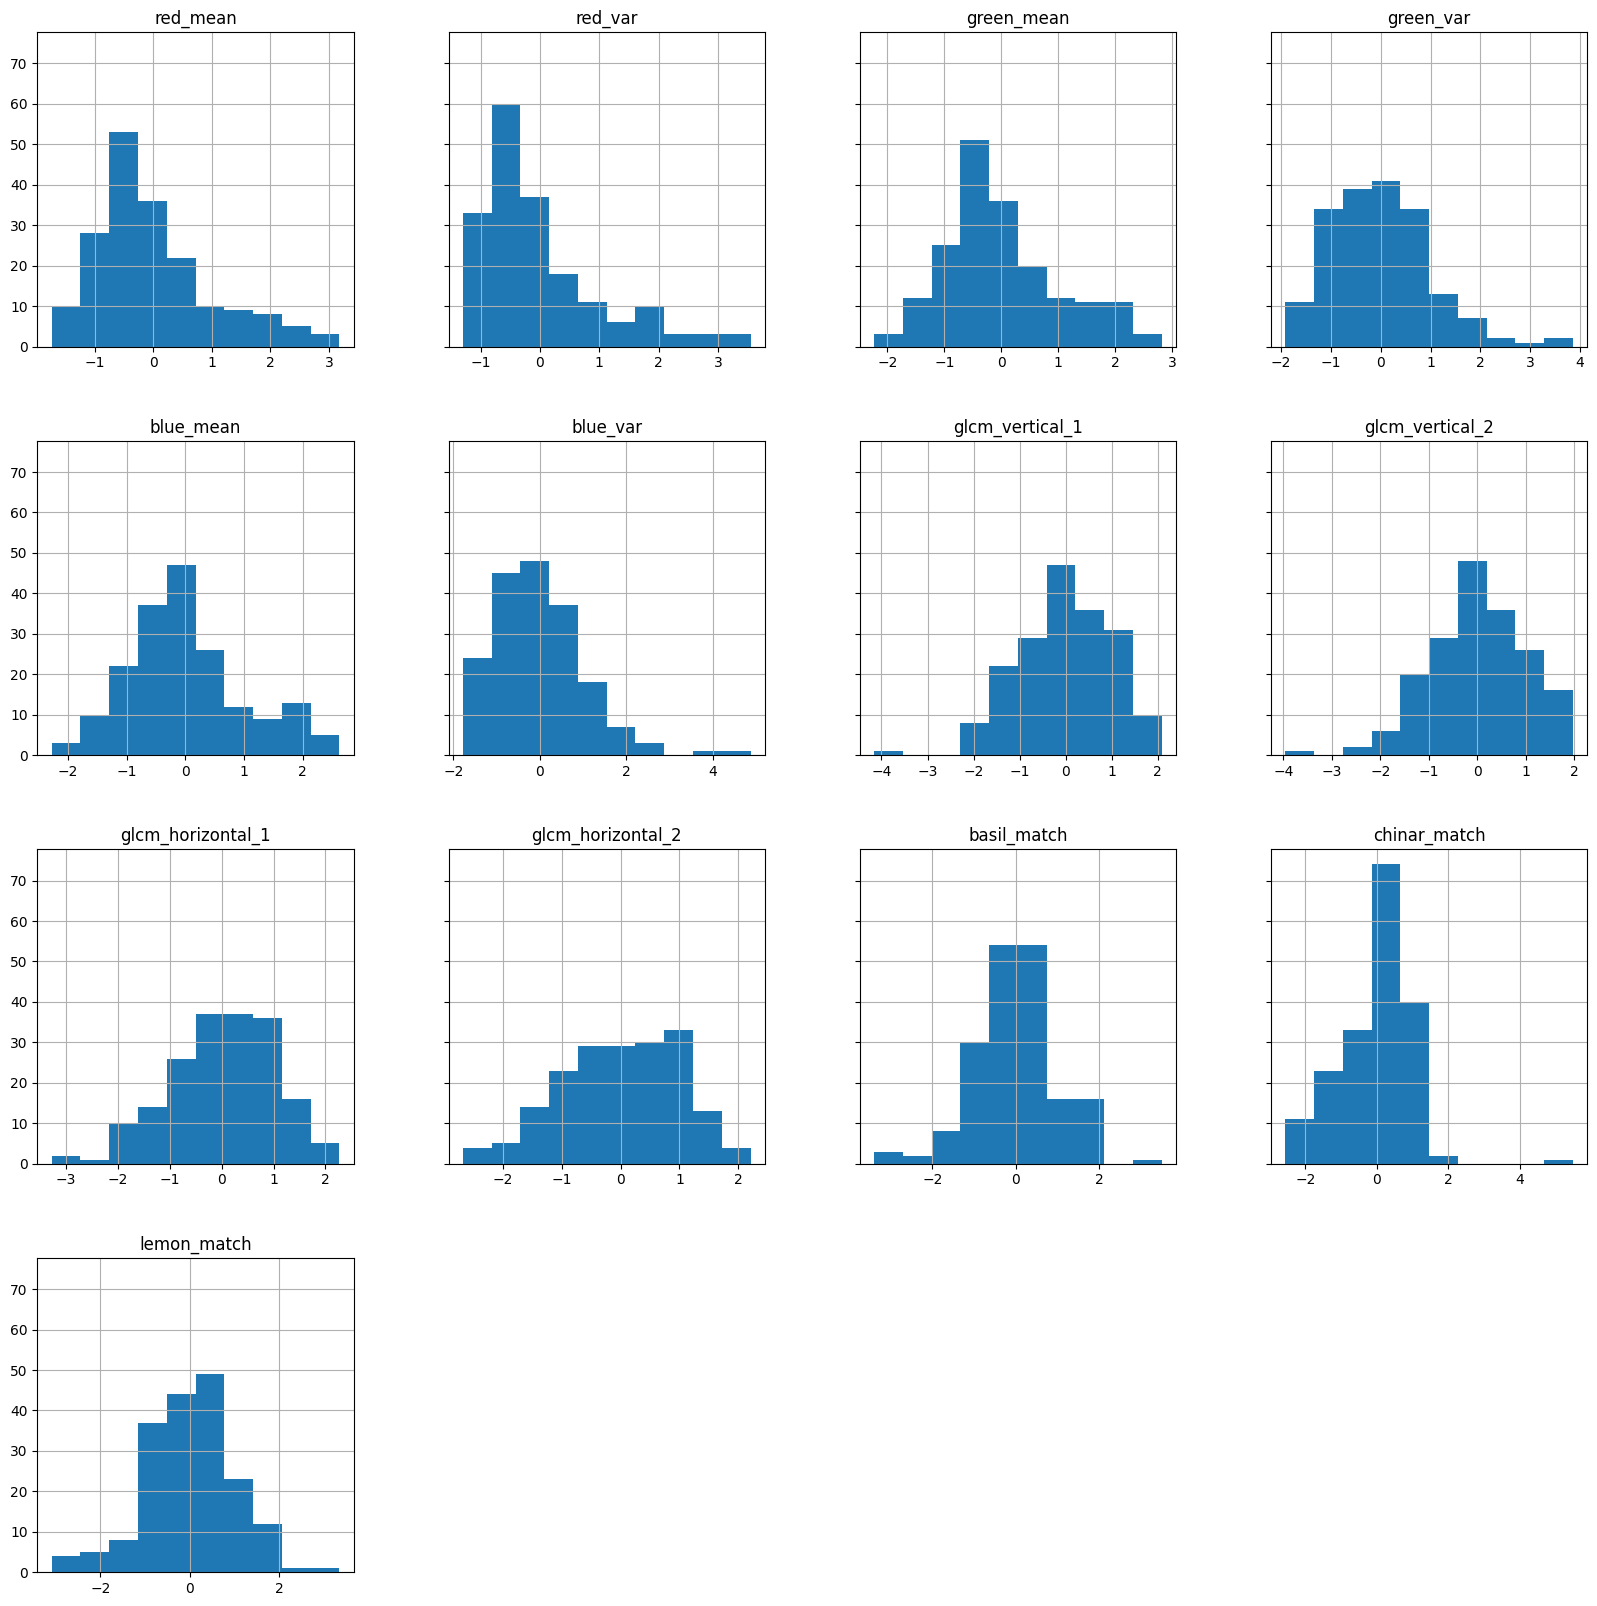

In [31]:
#Histograms for each feature
ax = X.hist(figsize=(20, 20), sharey=True)

<Axes: ylabel='Count'>

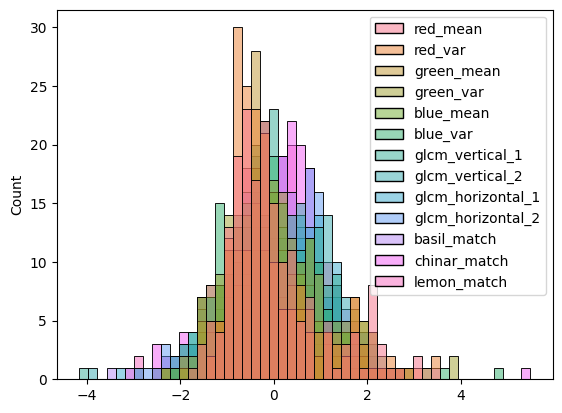

In [32]:
sns.histplot(X)

Based on the histograms there doesn't seem to be any noticeably discriminative features. The discriminative power of a feature tells how much that feature is different for different classes and how similar it is within its own class. Good discriminative features have strong and different responses for different classes but a similar response for classes of the same type. All of the features in the feature vector follow a similar distribution in the histogram so figuring out which of them is the most discriminative is difficult 

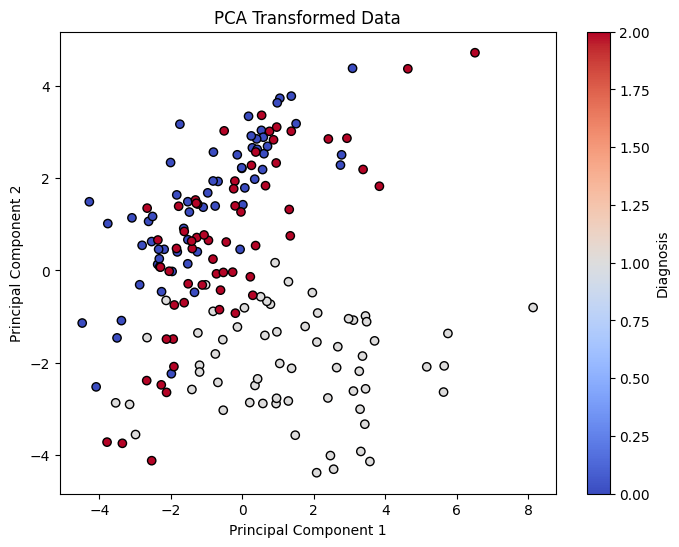

In [33]:
#PCA
#Labels 0: basil, 1: chinar, 2: lemon

pca = sk.decomposition.PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")
plt.colorbar(label="Diagnosis")
plt.show()


There are two distinct cluster in the PCA plot. These clusters correspond to the Basil and Lemon features being similar and Chinar being different from them, but forming a coherent group. This is a good result for the PCA, beacuse from visual analysis the Basil and Lemon leaves are more similar with eachother than Chinar leaves.

In [34]:
#Test, train split using 30% for test and 70% for train

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [35]:
#Nested cross validation, which needs the model and it's parameters
#The inner loop finds the best hyperparameters for the selected model
#The outer loop tests the best model with the unseen data

def nested_cross_validation(model, params):

    nested_scores = []

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    outer_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

    # Nested CV with parameter optimization
    clf = GridSearchCV(estimator=model, param_grid=params, cv=inner_cv, n_jobs=-1, scoring='accuracy', return_train_score=True)
    clf.fit(X_train, y_train)
        
    nested_score = cross_val_score(clf, X=X_test, y=y_test, cv=outer_cv, n_jobs=-1)
    nested_scores.append((nested_score, clf))

    return nested_scores

In [36]:
#Import given models and their parameter values

ridge_params = {
  'alpha': [0.001, 0.01, 0.1, 1.0], 
  }
ridge_classifier = sklm.RidgeClassifier()
forest_params = {
    'n_estimators': range(100, 350, 50),
    'max_features': ['sqrt','log2',None],
    'bootstrap': [True],
}
forest_classifier = RandomForestClassifier()
mlp_params = {
  'hidden_layer_sizes': [(1,15),(1,20),(1,25),(1,30),(1,35),(1,40)],
  'activation': ['tanh', 'relu'],
  'solver': ['sgd', 'adam'],
  'validation_fraction': [0.1, 0.3],
  'alpha': [0.01, 0.1, 1],
  }
mlp_classifier = MLPClassifier() 

ridge = nested_cross_validation(ridge_classifier, ridge_params)
forest = nested_cross_validation(forest_classifier, forest_params)
mlp = nested_cross_validation(mlp_classifier, mlp_params)

/home/asteer/data/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/asteer/data/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/asteer/data/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/asteer/data/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/asteer/data/lib/python3.12/site-packages/sklearn/n

In [37]:
#Function for reporting params, rank test score, mean test score and std test score

def print_results(model, isForest):
  if(isForest):
    importances = forest[0][1].best_estimator_.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
    print(feature_imp_df)
  
  results_df = pd.DataFrame(model[0][1].cv_results_)
  results_df = results_df.sort_values(by=["rank_test_score"])
  results_df = results_df.set_index(
      results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
  ).rename_axis("kernel")
  print(results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]])

In [44]:
#Print results that show all tested hyperparameters and their performance

print("Ridge Classifier")
print_results(ridge, False)
print("Random Forest")
print_results(forest, True)
print("MLP")
print_results(mlp, False)

Ridge Classifier
                  params  rank_test_score  mean_test_score  std_test_score
kernel                                                                    
1.0       {'alpha': 1.0}                1         0.937538        0.019007
0.001   {'alpha': 0.001}                2         0.929538        0.029965
0.01     {'alpha': 0.01}                2         0.929538        0.029965
0.1       {'alpha': 0.1}                4         0.921538        0.025817
Random Forest
              Feature  Gini Importance
11       chinar_match         0.196768
0            red_mean         0.155764
1             red_var         0.134294
2          green_mean         0.091240
4           blue_mean         0.074452
9   glcm_horizontal_2         0.065860
8   glcm_horizontal_1         0.054425
10        basil_match         0.052595
12        lemon_match         0.044367
7     glcm_vertical_2         0.037460
3           green_var         0.037186
5            blue_var         0.028980
6     glcm_v

These are the selected hyperparameters for each model
Best parameters for Ridge Classifier are alpha = 1.0

Best parameters for Random Forest are n_estimators = 150, max_features = sqrt, bootstrap = True

The most important features with a gini score of above 0.1 are 
chinar_match         0.196768
red_mean         0.155764
red_var         0.134294

These parameters do match the previous observations for the most disrciminant features and they also show that most of the features are not that important.

Best parameters for MLP are number of neurons = 30, activation function = tanh, solver = Adam,
validation factor of 0.3 and the L2 regularization strength = 1

In [ ]:
#Predict labels using best models

ridge_y = ridge[0][1].predict(X)
forest_y = forest[0][1].predict(X)
mlp_y = mlp[0][1].predict(X)

labels = ['Basil', 'Chinar', 'Lemon']
cm_ridge = confusion_matrix(y, ridge_y)
cm_forest = confusion_matrix(y, forest_y)
cm_mlp = confusion_matrix(y, mlp_y)

In [ ]:
#Function for printing a confusion matrix

def conf_matrix(cm, labels, title):
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  disp.plot(cmap=plt.cm.Blues)
  plt.title(title, fontsize=15, pad=20)
  plt.xlabel('Prediction', fontsize=11)
  plt.ylabel('Actual', fontsize=11)
  plt.gca().xaxis.set_label_position('top')
  plt.gca().xaxis.tick_top()
  plt.gca().figure.subplots_adjust(bottom=0.2)
  plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

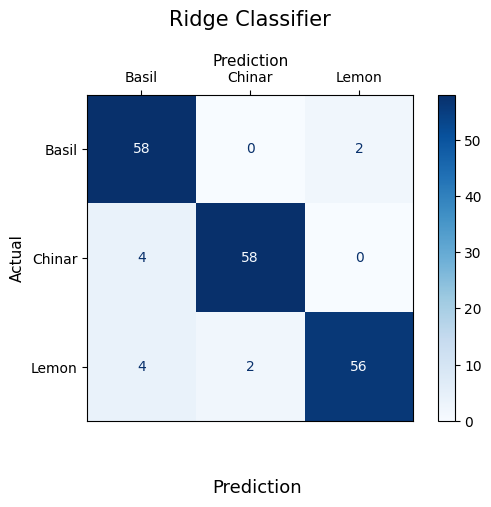

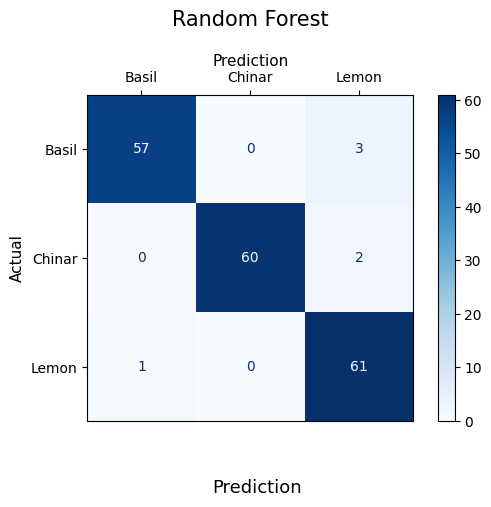

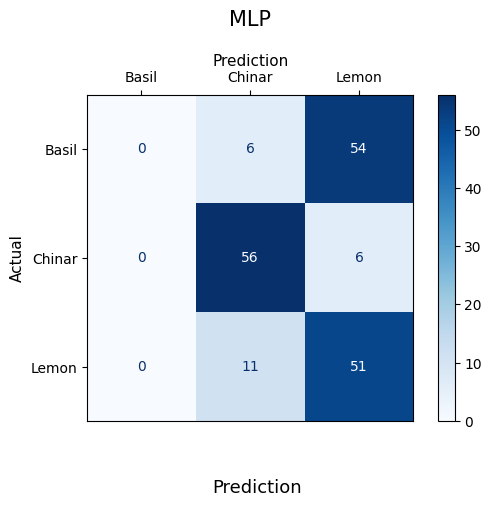

In [45]:
#Function calls to print confusion matrix

conf_matrix(cm_ridge, labels, 'Ridge Classifier')
conf_matrix(cm_forest, labels, 'Random Forest')
conf_matrix(cm_mlp, labels, 'MLP')

The result of the confusion matrix for each model is as follows.

The Ridge Classifier managed to correctly label 58 Basil, 58 Chinar and 56 Lemon with most mislabels being Lemon and Basil being confused. Total number of misclassification is 12.

The Random Forest classifier managed to correctly label 57 Basil, 60 Chinar and 61 Lemon with only having 6 mislabelled leaves.

The MLP performed worst out of all of the models with no correct labels for Basil. It was reasonably good at identifying Chinar, but it classified almost all of the Basil as being lemon.

In [ ]:
#Print the precision, recall, f1-score and support for each confusion matrix

print(classification_report(y, ridge_y, target_names=labels))
print(classification_report(y, forest_y, target_names=labels))
print(classification_report(y, mlp_y, target_names=labels))

              precision    recall  f1-score   support

       Basil       0.88      0.97      0.92        60
      Chinar       0.97      0.94      0.95        62
       Lemon       0.97      0.90      0.93        62

    accuracy                           0.93       184
   macro avg       0.94      0.94      0.93       184
weighted avg       0.94      0.93      0.94       184

              precision    recall  f1-score   support

       Basil       0.98      0.95      0.97        60
      Chinar       1.00      0.97      0.98        62
       Lemon       0.92      0.98      0.95        62

    accuracy                           0.97       184
   macro avg       0.97      0.97      0.97       184
weighted avg       0.97      0.97      0.97       184

              precision    recall  f1-score   support

       Basil       0.00      0.00      0.00        60
      Chinar       0.77      0.90      0.83        62
       Lemon       0.46      0.82      0.59        62

    accuracy        

/home/asteer/data/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/asteer/data/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/asteer/data/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
#Print the mean accuracy of the outer folds.

print(ridge[0][1].cv_results_['mean_test_score'].mean())
print(forest[0][1].cv_results_['mean_test_score'].mean())
print(mlp[0][1].cv_results_['mean_test_score'].mean())

0.9295384615384616
0.9007179487179487
0.5787521367521368


The mean accuracy of the outer folds is the mean accuracy of each model for the unseen test set for all folds. This value is used for measuring the generalization performance of each model.

## Discussion

The Random Forest Classifier performed the best for this task. RFC is works well with classification tasks where there are high dimensions of feature data. This means that for this task where there was over ten features with each of them being almost equal, the RFC can still produce the best outcome out of all of the models.

The Ridge Regression Classifier performed almost as well as the Random Forest Classifier. The performance of this model is affected by the number of irrelevant features, which increases the computation cost and decreases this models performance. Because there are a lot of overlapping and not important features in the data, RRC can't perform optimally.

The Multi Layer Perceptron suffers from the same problem as the RRC. The dependencies in the data are linear and there are many features, that don't offer a great deal of variance between classes. This means that the MLP classifier has too many useless inputs and the prediction capability of this model suffers. MLP is good for non linear tasks.

The limitations for the approach of this task is the limited number of sample pictures and the computational power that is required for training more complex classifiers. Because the sample size is small, the effect of random chance in the data is higher than normal. To imporve this approach, there should be more available pictures and the features that are extracted from the data should provide better features. Also removing useless features should help MLP and RRC classifiers.